## This Week’s Fiddler

My friend has three cups, labeled “A,” “B,” and “C” in a row. She picks two random cups and swaps their position. Then she does this again and again, picking a random pair each time, until all three cups are back in their original order. For example, here is one such sequence of swaps:

  - A, B, C (original)
  - C, B, A (first and third were swapped)
  - B, C, A (first and second were swapped)
  - B, A, C (second and third were swapped)
  - A, B, C (first and second were swapped)

In this example, the cups returned to their original order after four swaps.

On average, how many swaps would you expect until the cups return to their original order?

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
def swap(s, n):
    if n == 0:
        return s[1]+s[0]+s[2]
    elif n == 1:
        return s[0]+s[2]+s[1]
    elif n == 2:
        return s[2]+s[1]+s[0]

s="ABC"
for i in range(3):
    print(f"swap('{s}', {i}) -> {swap(s, i)}")

swap('ABC', 0) -> BAC
swap('ABC', 1) -> ACB
swap('ABC', 2) -> CBA


In [3]:
def sim(sInit):
    n = 0
    s = sInit
    while not (s == sInit and n > 0):
        s = swap(s, random.randint(0, 2))
        n += 1
        #print(s, n)
    return n

sim("ABC")

6

In [6]:
def simN(n):
    out = []
    for _ in range(n):
        out.append(sim("ABC"))
    return np.array(out)

data = simN(100000)
data

array([ 6,  4,  2, ...,  6, 14, 10])

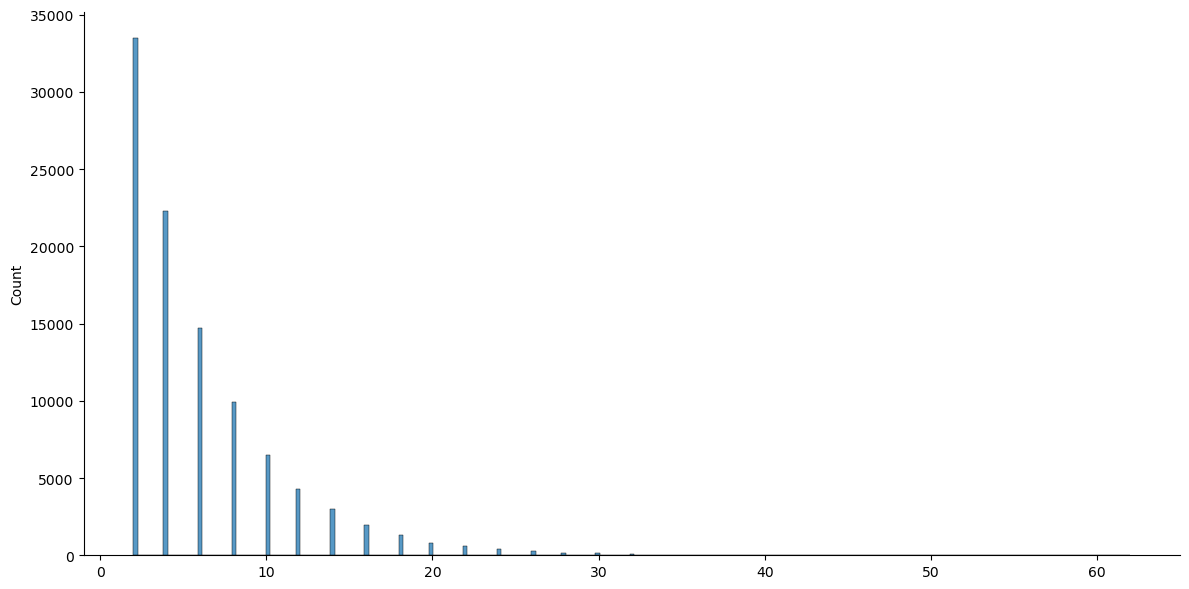

In [8]:
sns.displot(data, height=6, aspect=2)
plt.show()